# Q1 — Radon Transform (Shepp-Logan)
Implementations: myXrayIntegration, myXrayCTRadonTransform and comparisons.

In [30]:
import numpy as np
import matplotlib.pyplot as plt
from skimage.data import shepp_logan_phantom
from skimage.transform import resize
from scipy.interpolate import RegularGridInterpolator

In [31]:
# generate phantom and set coordinate frame
N = 128
phantom = shepp_logan_phantom()
f = resize(phantom, (N, N), order=1, mode='constant', anti_aliasing=True)
ys = np.arange(N) - (N-1)/2.0
xs = np.arange(N) - (N-1)/2.0

In [32]:

def myXrayIntegration(img, t, theta_deg, ds=1.0, interp_kind='linear'):
    """
    Integrate image intensities along line L_{t,theta}.
    - img: 2D numpy array (origin = center pixel)
    - t: signed distance (pixel units)
    - theta_deg: angle in degrees (measured from +x axis)
    - ds: step size along the line (in pixels)
    Returns: scalar integral ≈ ds * sum( I(x(s), y(s)) ).
    """
    theta = np.deg2rad(theta_deg)

    # line center (signed distance t along normal)
    x0 = t * np.cos(theta)
    y0 = t * np.sin(theta)

    # sample s along the line long enough to cross the image
    max_len = 0.5 * np.sqrt(img.shape[0]**2 + img.shape[1]**2)
    s = np.arange(-max_len, max_len + ds/2, ds)

    # Cartesian line parameterization (x,y) for s
    xs = x0 - s * np.sin(theta)

    # IMPORTANT: image row coordinate increases DOWNWARD, so flip y sign here.
    # Standard Cartesian y = t*sin(theta) + s*cos(theta).
    # Image row index (to feed interpolator) should be the negative of that.
    ys = -(y0 + s * np.cos(theta))

    # Build interpolator with coordinates centered on the image center:
    # first axis = rows (y), second axis = cols (x).
    y_coords = np.arange(img.shape[0]) - (img.shape[0] - 1) / 2.0
    x_coords = np.arange(img.shape[1]) - (img.shape[1] - 1) / 2.0
    interp = RegularGridInterpolator((y_coords, x_coords),
                                     img,
                                     method=interp_kind,
                                     bounds_error=False,
                                     fill_value=0.0)

    pts = np.vstack((ys, xs)).T   # shape (len(s), 2) with (y, x) order
    vals = interp(pts)
    return np.sum(vals) * ds


In [33]:
def myXrayCTRadonTransform(img, t_vals, theta_vals, ds=1.0):
    """
    Compute discrete Radon transform R(t,theta) for arrays t_vals, theta_vals.
    Returns array with shape (len(t_vals), len(theta_vals)).
    """
    R = np.zeros((len(t_vals), len(theta_vals)), dtype=float)
    for i, t in enumerate(t_vals):
        for j, th in enumerate(theta_vals):
            R[i, j] = myXrayIntegration(img, t, th, ds=ds)
    return R

In [34]:
t_vals = np.arange(-90, 95, 5)
theta_vals = np.arange(0, 180, 5)
ds_list = [0.5, 1.0, 3.0]
radons = {ds: myXrayCTRadonTransform(f, t_vals, theta_vals, ds=ds) for ds in ds_list}

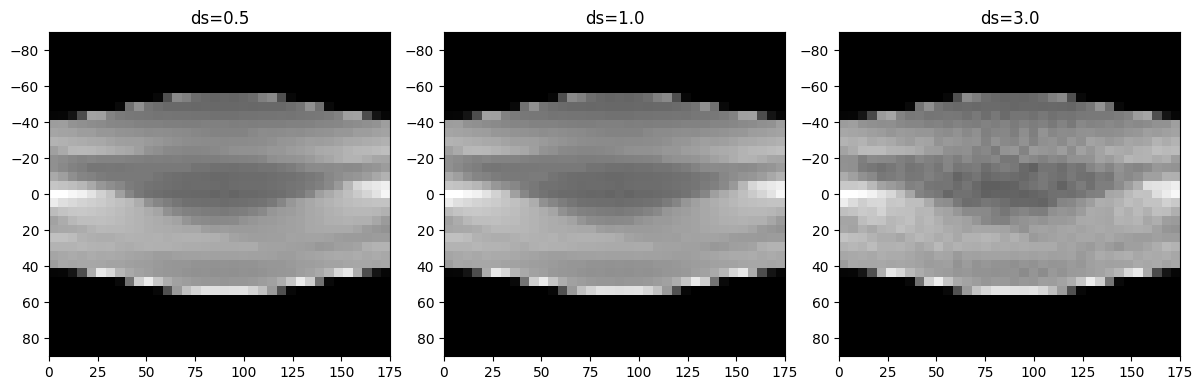

In [35]:
fig, axs = plt.subplots(1,3, figsize=(12,4))
for ax, ds in zip(axs, ds_list):
    ax.imshow(radons[ds], aspect='auto', cmap='gray', extent=[theta_vals[0], theta_vals[-1], t_vals[-1], t_vals[0]])
    ax.set_title(f'ds={ds}')
plt.tight_layout()

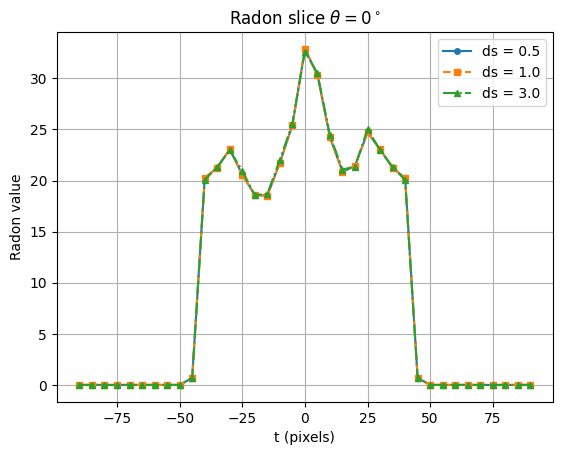

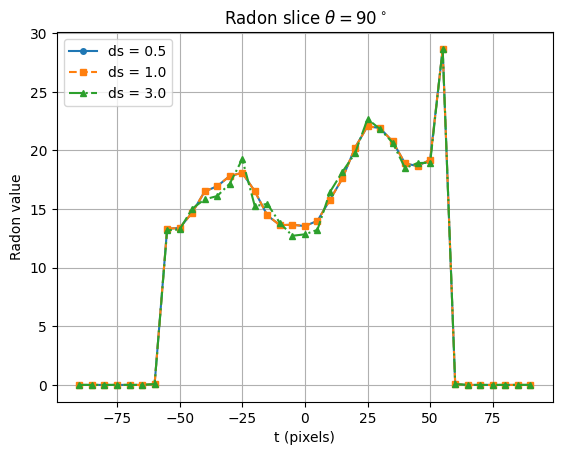

In [36]:
# plot 1D slices for theta=0 and theta=90
markers = {0.5: 'o', 1.0: 's', 3.0: '^'}   # circle, square, triangle
linestyles = {0.5: '-', 1.0: '--', 3.0: '-.'}

for angle in [0, 90]:
    idx = int(angle / 5)
    plt.figure()
    for ds in ds_list:
        plt.plot(
            t_vals,
            radons[ds][:, idx],
            marker=markers[ds],
            linestyle=linestyles[ds],
            markersize=4,
            label=f'ds = {ds}'
        )
    plt.title(f'Radon slice $\\theta = {angle}^\\circ$')
    plt.xlabel('t (pixels)')
    plt.ylabel('Radon value')
    plt.legend()
    plt.grid(True)
    plt.show()

Notes:
- Chosen ds values: 0.5, 1, 3 (smaller ds gives smoother approximation).
- Interpolation: linear via RegularGridInterpolator (balance of accuracy and speed).

In [37]:
from skimage.data import shepp_logan_phantom
from skimage.transform import radon, resize
import numpy as np

# phantom and params
img = resize(shepp_logan_phantom(), (128,128), order=1, preserve_range=True).astype(float)
t_vals = np.arange(-90, 95, 5)
theta_vals = np.arange(0, 180, 5)

# compute
R_my = myXrayCTRadonTransform(img, t_vals, theta_vals, ds=1.0)
R_ref = radon(img, theta=theta_vals, circle=False)

# interpolate skimage detectors to t_vals (center coordinates)
det_len = R_ref.shape[0]
det_coords = np.arange(det_len) - (det_len - 1)/2.0
R_ref_interp = np.zeros((len(t_vals), len(theta_vals)))
for j in range(len(theta_vals)):
    R_ref_interp[:, j] = np.interp(t_vals, det_coords, R_ref[:, j], left=0, right=0)

# errors
def rel_l2(A,B):
    A = np.asarray(A, dtype=float); B = np.asarray(B, dtype=float)
    An = A / np.linalg.norm(A)
    Bn = B / np.linalg.norm(B)
    return np.linalg.norm(An - Bn) / np.linalg.norm(Bn)

print("L2 (Frobenius):", np.linalg.norm(R_my/np.linalg.norm(R_my) - R_ref_interp/np.linalg.norm(R_ref_interp)))
print("Relative L2:", rel_l2(R_my, R_ref_interp))


L2 (Frobenius): 0.09111790815036294
Relative L2: 0.09111790815036296
